# Grasp adaptation — gradient-descent force control

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as _mpatch
import os, sys
from pathlib import Path

sys.path.insert(0, os.path.join('../'))
from plot_config import draw_radar
from hand_config import (K_TIP_GENTLE, GD_LR, F_CONVERGE_THR,
                         FORCE_LEVELS, F_DES)
from ModelIDHand.hand_viz import plot_hand, _COL

OUTPUT_DIR = os.path.join('outputs', 'grasp_adaptation')
os.makedirs(OUTPUT_DIR, exist_ok=True)

FINGERTIPS   = ['thumb', 'index', 'middle', 'ring', 'pinky']
LEVEL_LABELS = {'hard': 'Hard', 'medium': 'Medium', 'soft': 'Soft'}
LEVEL_COLOR  = {'hard': 'C0', 'medium': 'C2', 'soft': 'C1'}

_Q_COLS    = [f'q_motor_{i}_rad' for i in range(13)]
_STYLE     = dict(linestyle='-', linewidth=4.5, marker='o', markersize=6.0)
_ELEV, _AZIM = 22, 112


def load(level):
    folder = Path(OUTPUT_DIR)
    if not folder.exists():
        return None
    files = sorted(folder.glob(f'grasp_{level}.csv'))
    return pd.read_csv(files[-1]) if files else None


def _steady(df, phase, frac=0.2):
    rows = df[df['phase'] == phase]
    return rows.tail(max(1, int(len(rows) * frac))) if not rows.empty else rows


def _polish_ax(ax, title):
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlabel(''); ax.set_ylabel(''); ax.set_zlabel('')
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.fill = False
        pane.set_edgecolor('#d8d8d8')
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis._axinfo['grid']['color']     = (0.88, 0.88, 0.88, 0.6)
        axis._axinfo['grid']['linewidth'] = 0.4
    ax.view_init(elev=_ELEV, azim=_AZIM)
    ax.set_title(title, fontsize=plt.rcParams['axes.titlesize'],
                 fontweight='semibold', pad=14, color='#1a1a1a')


def _sync_axes(axes):
    lims = np.array([[a.get_xlim3d(), a.get_ylim3d(), a.get_zlim3d()] for a in axes])
    xl = [lims[:,0,0].min(), lims[:,0,1].max()]
    yl = [lims[:,1,0].min(), lims[:,1,1].max()]
    zl = [lims[:,2,0].min(), lims[:,2,1].max()]
    span = max(xl[1]-xl[0], yl[1]-yl[0], zl[1]-zl[0])
    cx, cy, cz = 0.5*sum(xl), 0.5*sum(yl), 0.5*sum(zl)
    for a in axes:
        a.set_xlim3d(cx-span/2, cx+span/2)
        a.set_ylim3d(cy-span/2, cy+span/2)
        a.set_zlim3d(cz-span/2, cz+span/2)


data = {level: load(level) for level in FORCE_LEVELS}
print('Loaded:')
for level in FORCE_LEVELS:
    df = data[level]
    print(f'  {level}: {len(df)} rows' if df is not None else f'  {level}: no data')

Loaded:
  hard: 224 rows
  medium: no data
  soft: 227 rows


## Radar: fingertip force distribution — GD start vs end

Three panels (one per force level). Each radar shows $|F_{\rm tip}|$ per finger
at the **start** (first 20 % of `adapt_gd`) and **end** (last 20 %) of the gradient-descent phase.

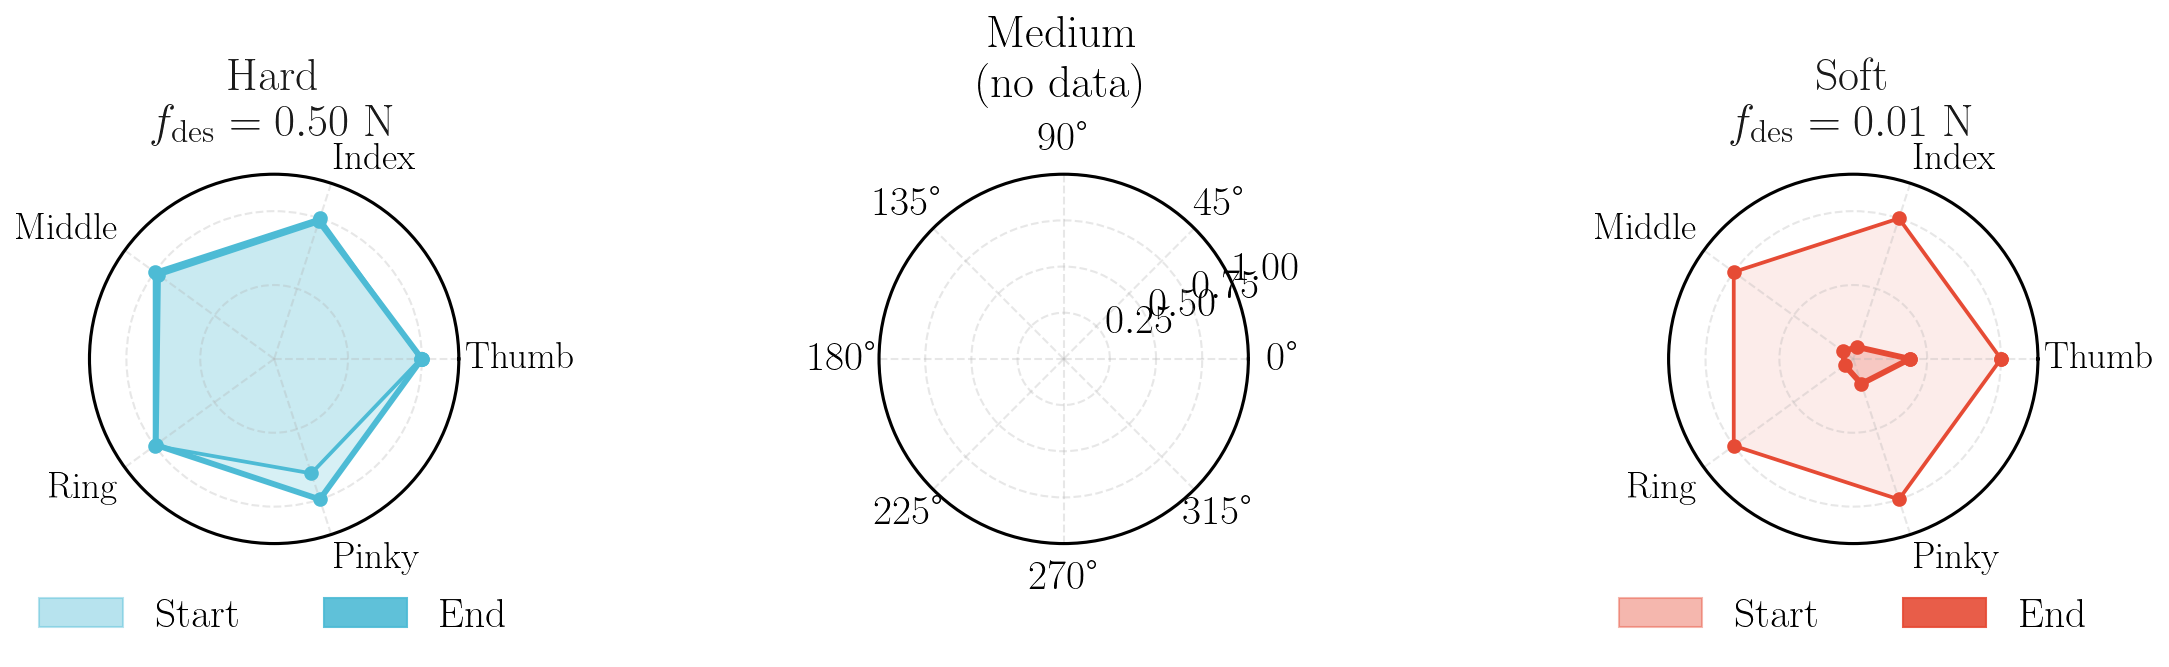

In [7]:
fig, axes = plt.subplots(1, 3, subplot_kw=dict(projection='polar'),
                         figsize=(16, 5))

for ax, level in zip(axes, FORCE_LEVELS):
    df = data[level]
    if df is None:
        ax.set_title(f'{LEVEL_LABELS[level]}\n(no data)')
        continue

    gd = df[df['phase'] == 'adapt_gd']
    if gd.empty:
        ax.set_title(f'{LEVEL_LABELS[level]}\n(no adapt_gd)')
        continue

    n     = max(1, len(gd) // 5)
    snaps = [('Start', gd.head(n), 0.10, 1.8),
             ('End',   gd.tail(n), 0.22, 2.8)]

    traces = []
    for label, rows, alpha, lw in snaps:
        forces = [float(rows[f'f_meas_gd_{f}_mag_N'].mean()) for f in FINGERTIPS]
        traces.append({'label': label, 'values': forces,
                       'color': LEVEL_COLOR[level], 'lw': lw, 'alpha': alpha})

    draw_radar([f.capitalize() for f in FINGERTIPS], traces, ax=ax)

    f_des_mag = F_DES[level]
    ax.set_title(f'{LEVEL_LABELS[level]}\n$f_{{\\rm des}}={f_des_mag:.2f}$ N',
                 fontsize=plt.rcParams['axes.titlesize'],
                 fontweight='semibold', pad=18, color='#1a1a1a')

    handles = [_mpatch.Patch(color=LEVEL_COLOR[level], alpha=0.4, label='Start'),
               _mpatch.Patch(color=LEVEL_COLOR[level], alpha=0.9, label='End')]
    ax.legend(handles=handles, loc='lower center',
              bbox_to_anchor=(0.5, -0.35), ncol=2, frameon=False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'radar_force_gd.pdf'))
plt.show()

## Mean fingertip force evolution during GD

Mean $|F_{\rm tip}|$ across all five fingers over time in the `adapt_gd` phase.
Dashed line = $f_{\rm des}$ target. All three force levels on the same axes.

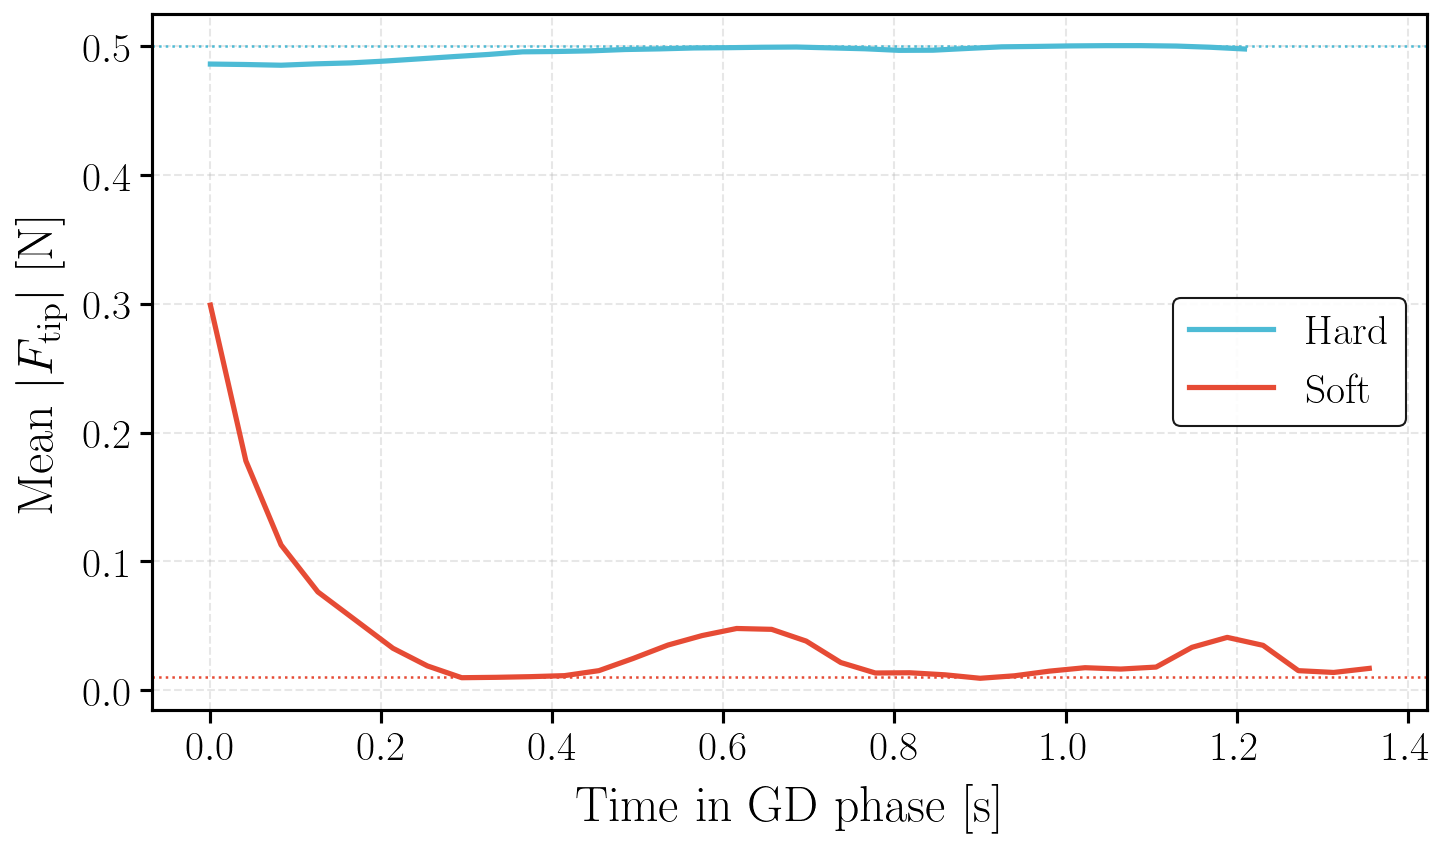

In [8]:
fig, ax = plt.subplots()

for level in FORCE_LEVELS:
    df = data[level]
    if df is None:
        continue
    gd = df[df['phase'] == 'adapt_gd']
    if gd.empty:
        continue
    t0    = gd['time_s'].iloc[0]
    f_mag = np.stack([gd[f'f_meas_gd_{f}_mag_N'].to_numpy() for f in FINGERTIPS], axis=1).mean(axis=1)
    ax.plot(gd['time_s'] - t0, f_mag,
            color=LEVEL_COLOR[level], lw=2.5, label=LEVEL_LABELS[level])
    f_des = F_DES[level]
    ax.axhline(f_des, color=LEVEL_COLOR[level], lw=1.2, ls=':')

ax.set_xlabel('Time in GD phase [s]')
ax.set_ylabel(r'Mean $|F_{\rm tip}|$ [N]')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fingertip_force_gd.pdf'))
plt.show()

## Fingertip stiffness along contact normal during GD

Maximum eigenvalue of $K_{\rm tip}$ per finger (= stiffness along contact normal $\hat{n}$),
averaged across all five fingers. All three force levels on the same scale.

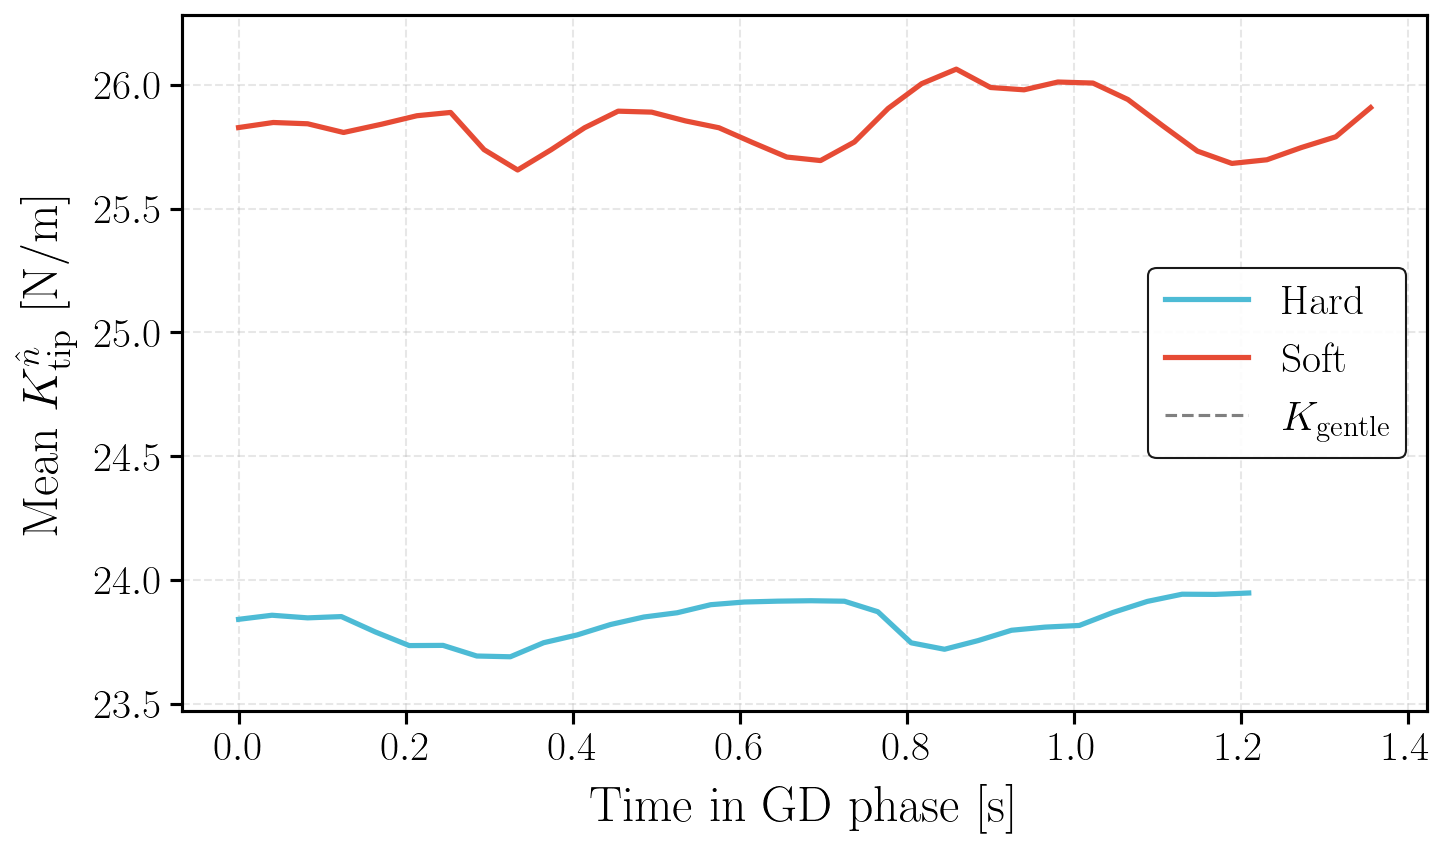

In [9]:
fig, ax = plt.subplots()

all_vals = []
for level in FORCE_LEVELS:
    df = data[level]
    if df is None:
        continue
    gd = df[df['phase'] == 'adapt_gd']
    if gd.empty:
        continue
    t0 = gd['time_s'].iloc[0]
    # max eigenvalue of K_tip per finger = stiffness along contact normal n
    K_n_fingers = np.stack([
        gd[f'stiff_1st_{f}_eig_2_Npm'].to_numpy() for f in FINGERTIPS
    ], axis=1)
    K_n_mean = K_n_fingers.mean(axis=1)
    ax.plot(gd['time_s'] - t0, K_n_mean,
            color=LEVEL_COLOR[level], lw=2.5, label=LEVEL_LABELS[level])
    all_vals.append(K_n_mean)

if all_vals:
    all_v = np.concatenate(all_vals)
    margin = (all_v.max() - all_v.min()) * 0.05 + 0.1
    ax.set_ylim(all_v.min() - margin, all_v.max() + margin)

ax.axhline(K_TIP_GENTLE, color='0.5', lw=1.5, ls='--',
           label=r'$K_{\rm gentle}$')
ax.set_ylabel(r'Mean $K_{\rm tip}^{\hat{n}}$ [N/m]')
ax.set_xlabel('Time in GD phase [s]')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'tip_stiffness_normal_gd.pdf'))
plt.show()

## Hand pose while pressing

Motor configuration $q$ at the midpoint of the `press` phase, one panel per force level.

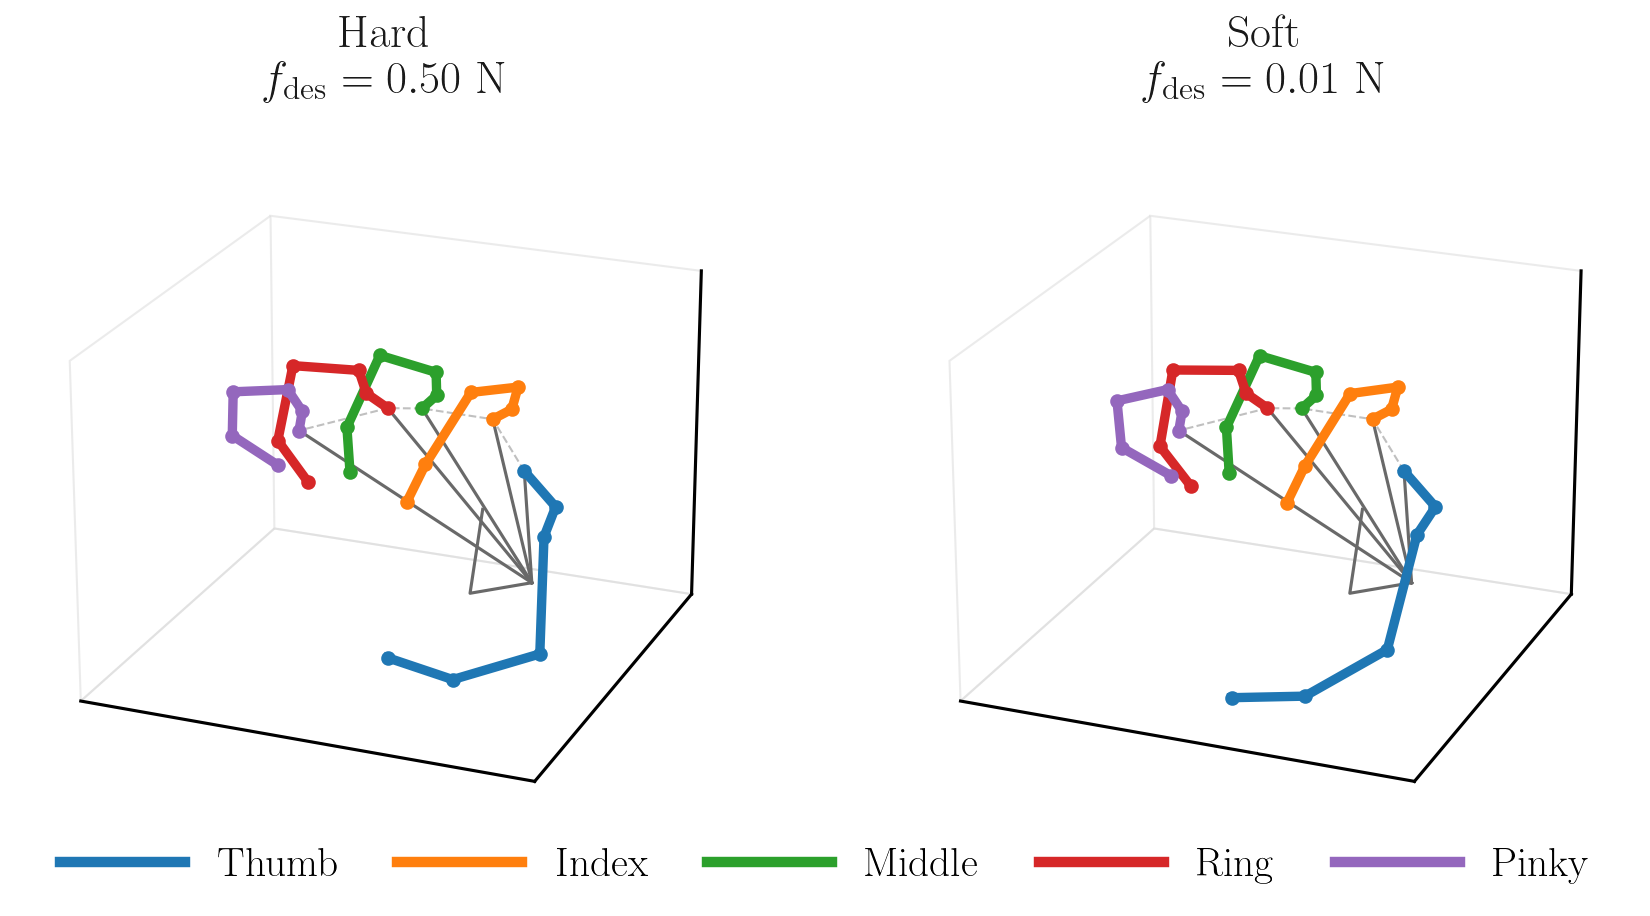

In [10]:
panels = [level for level in FORCE_LEVELS
          if data[level] is not None
          and not data[level][data[level]['phase'] == 'press'].empty]

if panels:
    fig = plt.figure(figsize=(6 * len(panels), 6))
    fig.patch.set_facecolor('white')
    axes3d = []
    for i, level in enumerate(panels):
        df    = data[level]
        press = df[df['phase'] == 'press']
        q     = press[_Q_COLS].iloc[len(press) // 2].to_numpy(dtype=np.float64)
        ax    = fig.add_subplot(1, len(panels), i + 1, projection='3d')
        plot_hand(q, ax=ax, style=_STYLE)
        leg = ax.get_legend()
        if leg: leg.remove()
        f_des = F_DES[level]
        _polish_ax(ax, f'{LEVEL_LABELS[level]}\n$f_{{\\rm des}}={f_des:.2f}$ N')
        axes3d.append(ax)

    _sync_axes(axes3d)
    _LEG = [plt.Line2D([0],[0], color=_COL[f], lw=5, label=f.capitalize())
            for f in FINGERTIPS]
    fig.legend(handles=_LEG, loc='lower center', ncol=5,
               fontsize=plt.rcParams['legend.fontsize'], frameon=False,
               bbox_to_anchor=(0.5, -0.02), handlelength=3.0, columnspacing=1.4)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, 'press_hand_pose.pdf'), dpi=300)
    plt.show()
else:
    print('No press-phase data found.')